# customer segmentation using k-means clustering

the goal here is to group customers into segments based on their buying behavior and how much they tend to buy in bad weather.

we build 4 features per customer:
- **recency** - how recently did they last order
- **frequency** - how many total orders they made
- **monetary** - how much they spend on average
- **weather sensitivity** - what % of their orders happened on rainy days

I did the visualization part with claude since i had no clue how to

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv('cleaned/master.csv', parse_dates=['purchase_date'])
print('loaded:', df.shape)

loaded: (88675, 23)


## step 1: build features per customer

In [2]:
ref_date = df['purchase_date'].max() + pd.Timedelta(days=1)

df['is_rainy'] = (df['precip_total_mm'] > 5).astype(int)

customer_df = df.groupby('customer_id').agg(
    recency     = ('purchase_date', lambda x: (ref_date - x.max()).days),
    frequency   = ('order_id', 'count'),
    monetary    = ('total_payment_value', 'mean'),
    weather_pct = ('is_rainy', 'mean')
).reset_index()

print('customers:', len(customer_df))
print()
customer_df.describe()

customers: 88675



,recency,frequency,monetary,weather_pct
count,88675.000000,88675.0,88674.000000,88675.000000
mean,238.677068,1.0,161.618607,0.161703
std,153.000927,0.0,222.341232,0.368180
min,1.000000,1.0,9.590000,0.000000
25%,116.000000,1.0,62.210000,0.000000
50%,217.000000,1.0,105.600000,0.000000
75%,346.000000,1.0,177.690000,0.000000
max,730.000000,1.0,13664.080000,1.000000


**note on frequency:** normally frequency is the most useful RFM feature. a customer who bought 8 times is obviously more loyal than someone who bought once. but look at the describe() output above: frequency std = 0.0, meaning literally every customer in this dataset ordered exactly once. olist is a marketplace where most people make a one-off purchase and never return, so frequency has zero variation and cant separate anyone. we keep it in the features list but it wont do anything. recency ends up doing the job instead, it at least tells us if someone bought recently or a long time ago.

## step 2: scale the features

In [3]:
features = ['recency', 'frequency', 'monetary', 'weather_pct']
X = customer_df[features].copy()

before = len(X)
X = X.dropna()
customer_df = customer_df.loc[X.index].copy()
print(f'dropped {before - len(X)} rows with NaN, {len(X)} remain')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('scaled shape:', X_scaled.shape)

dropped 1 rows with NaN, 88674 remain
scaled shape: (88674, 4)


## step 3: elbow method to pick the number of clusters

In [4]:
inertias = []
silhouettes = []
k_range = range(2, 10)

# silhouette on 88k rows takes forever so we just sample 5000
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=5000, replace=False)
X_sample = X_scaled[sample_idx]

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

    sample_labels = km.predict(X_sample)
    sil = silhouette_score(X_sample, sample_labels)
    silhouettes.append(sil)
    print(f'k={k}  inertia={km.inertia_:.1f}  silhouette={sil:.3f}')

k=2  inertia=177062.5  silhouette=0.541


k=3  inertia=121629.9  silhouette=0.478


k=4  inertia=77394.4  silhouette=0.509


k=5  inertia=64657.4  silhouette=0.519


k=6  inertia=54159.4  silhouette=0.448


k=7  inertia=45940.7  silhouette=0.447


k=8  inertia=40650.3  silhouette=0.460


k=9  inertia=36987.6  silhouette=0.457


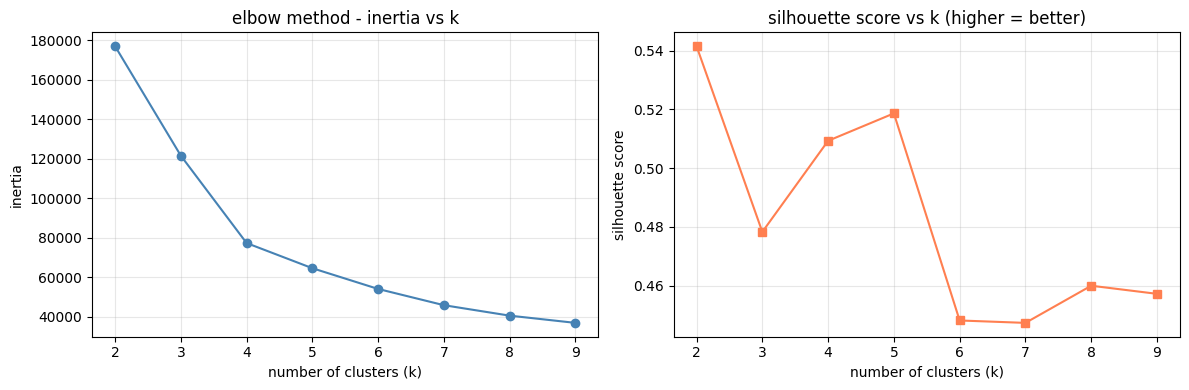

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_title('elbow method - inertia vs k')
axes[0].set_xlabel('number of clusters (k)')
axes[0].set_ylabel('inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), silhouettes, marker='s', color='coral')
axes[1].set_title('silhouette score vs k (higher = better)')
axes[1].set_xlabel('number of clusters (k)')
axes[1].set_ylabel('silhouette score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cleaned/plot_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

## step 4: run k-means with chosen k

based on the elbow and silhouette plots above we pick k. we'll go with **k=4** as a starting point, it usually gives interpretable segments for ecommerce data. adjust if the plots suggest otherwise.

In [6]:
K = 4

km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
customer_df['cluster'] = km_final.fit_predict(X_scaled)

print('cluster sizes:')
print(customer_df['cluster'].value_counts().sort_index())

cluster sizes:
cluster
0    42013
1     2152
2    30444
3    14065
Name: count, dtype: int64


## step 5: look at what each cluster actually means

In [7]:
cluster_summary = customer_df.groupby('cluster')[features].mean().round(2)
cluster_summary['n_customers'] = customer_df.groupby('cluster').size()

print('cluster averages:')
print(cluster_summary.to_string())

cluster averages:
         recency  frequency  monetary  weather_pct  n_customers
cluster                                                        
0         122.37        1.0    135.34         0.00        42013
1         237.01        1.0   1192.19         0.13         2152
2         390.06        1.0    135.42         0.00        30444
3         258.64        1.0    139.15         1.00        14065


## step 6: label the clusters based on what we see

after looking at the averages above we give each cluster a human-readable name. this is the most important step. turning math into something that actually makes sense for our analysis.

In [8]:
def label_cluster(row):
    if row['weather_pct'] >= 0.9:
        return 'weather-triggered buyer'
    elif row['monetary'] > 400:
        return 'high spender'
    elif row['recency'] < 200:
        return 'recent casual buyer'
    else:
        return 'inactive casual buyer'

cluster_summary['label'] = cluster_summary.apply(label_cluster, axis=1)

label_map = cluster_summary['label'].to_dict()
customer_df['segment'] = customer_df['cluster'].map(label_map)

print('final segment distribution:')
print(customer_df['segment'].value_counts())
print()
print('cluster averages with labels:')
print(cluster_summary[features + ['label', 'n_customers']].to_string())

final segment distribution:
segment
recent casual buyer        42013
inactive casual buyer      30444
weather-triggered buyer    14065
high spender                2152
Name: count, dtype: int64

cluster averages with labels:
         recency  frequency  monetary  weather_pct                    label  n_customers
cluster                                                                                 
0         122.37        1.0    135.34         0.00      recent casual buyer        42013
1         237.01        1.0   1192.19         0.13             high spender         2152
2         390.06        1.0    135.42         0.00    inactive casual buyer        30444
3         258.64        1.0    139.15         1.00  weather-triggered buyer        14065


## step 7: visualize the clusters

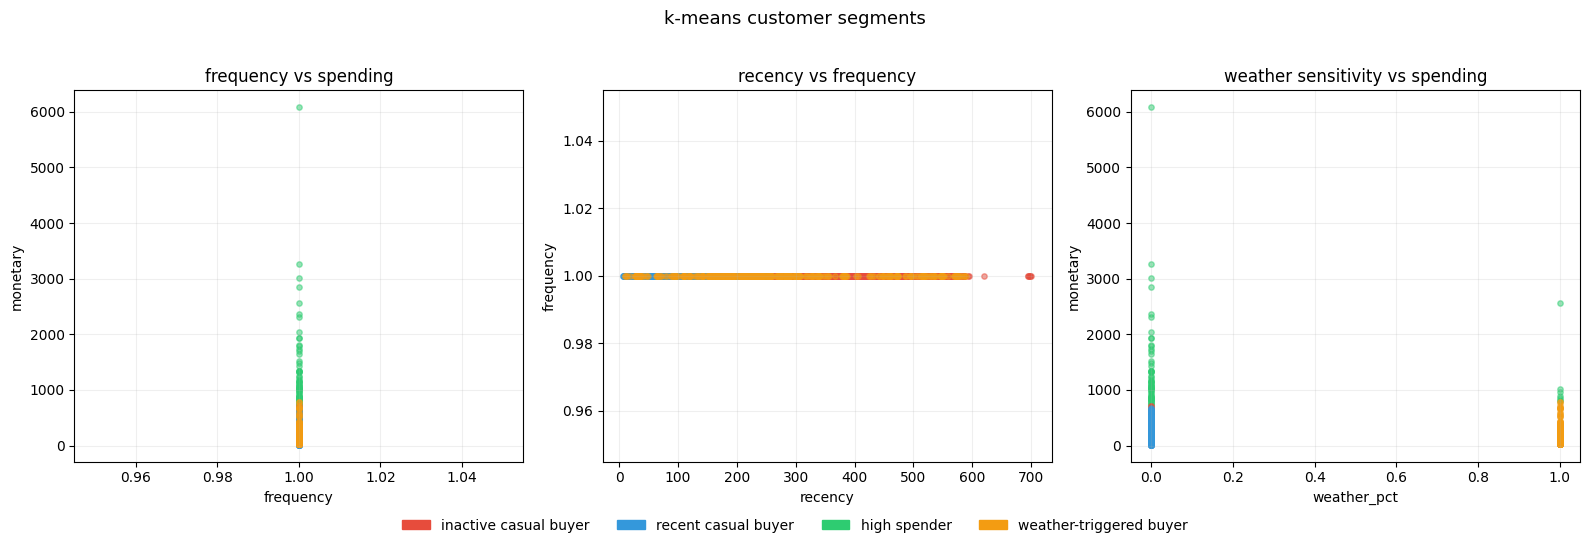

In [9]:
sample = customer_df.sample(min(3000, len(customer_df)), random_state=42)

segments = customer_df['segment'].unique()
colors_list = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
color_map = {seg: colors_list[i] for i, seg in enumerate(segments)}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [
    ('frequency',   'monetary',  'frequency vs spending'),
    ('recency',     'frequency', 'recency vs frequency'),
    ('weather_pct', 'monetary',  'weather sensitivity vs spending'),
]

for ax, (xcol, ycol, title) in zip(axes, pairs):
    for seg, grp in sample.groupby('segment'):
        ax.scatter(grp[xcol], grp[ycol], c=color_map[seg], label=seg, alpha=0.5, s=15)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(title)
    ax.grid(alpha=0.2)

handles = [mpatches.Patch(color=color_map[s], label=s) for s in segments]
fig.legend(handles=handles, loc='lower center', ncol=len(segments),
           bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.suptitle('k-means customer segments', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('cleaned/plot_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## step 8: bar chart of average features per cluster

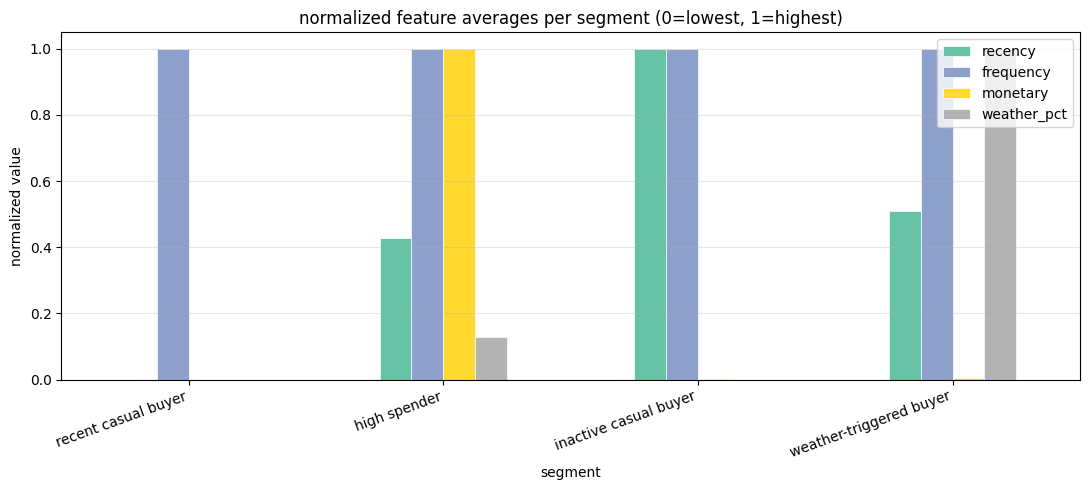

In [10]:
# normalize to 0-1 just so all features are on the same scale for the bar chart
norm_summary = cluster_summary[features].copy()
for col in features:
    rng = norm_summary[col].max() - norm_summary[col].min()
    if rng > 0:
        norm_summary[col] = (norm_summary[col] - norm_summary[col].min()) / rng

norm_summary.index = [label_map[c] for c in norm_summary.index]

ax = norm_summary.plot(kind='bar', figsize=(11, 5), colormap='Set2', edgecolor='white', linewidth=0.5)
ax.set_title('normalized feature averages per segment (0=lowest, 1=highest)')
ax.set_xlabel('segment')
ax.set_ylabel('normalized value')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cleaned/plot_cluster_bars.png', dpi=150, bbox_inches='tight')
plt.show()

## step 9: save the clustered customer data

In [11]:
customer_df.to_csv('cleaned/customers_clustered.csv', index=False)
print('saved customers_clustered.csv')
print(customer_df[['customer_id', 'cluster', 'segment', 'recency', 'monetary', 'weather_pct']].head(10).to_string())

saved customers_clustered.csv
                        customer_id  cluster                segment  recency  monetary  weather_pct
0  00012a2ce6f8dcda20d059ce98491703        2  inactive casual buyer      294    114.74          0.0
1  000161a058600d5901f007fab4c27140        2  inactive casual buyer      415     67.41          0.0
2  0001fd6190edaaf884bcaf3d49edf079        2  inactive casual buyer      553    195.42          0.0
3  0002414f95344307404f0ace7a26f1d5        2  inactive casual buyer      384    179.35          0.0
4  000379cdec625522490c315e70c7a9fb        0    recent casual buyer      155    107.01          0.0
5  0004164d20a9e969af783496f3408652        2  inactive casual buyer      510     71.80          0.0
6  00046a560d407e99b969756e0b10f282        2  inactive casual buyer      260    166.59          0.0
7  00050bf6e01e69d5c0fd612f1bcfb69c        2  inactive casual buyer      352     85.23          0.0
8  000598caf2ef4117407665ac33275130        1           high spender   

## summary of what we found

we ended up with 4 customer segments:

| segment | recency | monetary | weather_pct | count |
|---|---|---|---|---|
| weather-triggered buyer | ~258 days | ~139 BRL | **100%** | 14,065 |
| high spender | ~237 days | ~1,192 BRL | 13% | 2,152 |
| recent casual buyer | ~122 days | ~135 BRL | 0% | 42,013 |
| inactive casual buyer | ~390 days | ~135 BRL | 0% | 30,444 |

the most interesting one for our project is **weather-triggered buyer**. these are customers whose 100% of orders happened on rainy days. thats 14,065 people. the next step is to check whether these customers cancel more often than the others.

note: almost all customers in this dataset only ordered once (frequency = 1). this is actually typical for the olist dataset. most people use it for a one-off purchase. so frequency ended up not being a useful feature for separating clusters as i intended to, but recency, monetary, and especially weather_pct did the heavy lifting.